In [1]:
# # Install standard data science libraries
# %pip install requests numpy matplotlib
#
# # Install PyTorch with GPU support (CUDA 12.x)
# # Note: Since your driver supports 13.1, it can easily handle the stable 12.x versions.
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

In [2]:
# Imports
import math
import requests
import json
import os
import re
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter

In [3]:
# PART 1: Embeddings and Positional Encoding
class InputEmbeddings(nn.Module):
    def __init__(self, d_model, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.d_model = d_model

    def forward(self, x):
        # Scaling by sqrt(d_model) is standard in Transformer papers
        return self.embedding(x) * math.sqrt(self.d_model)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x shape: (Batch, Seq_Len, d_model)
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, q, k, v, mask=None):
        # q, k, v: (Batch, Heads, Seq_Len, d_k)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_k)

        if mask is not None:
            # Apply mask (set positions to -infinity so softmax makes them 0)
            scores = scores.masked_fill(mask == 0, -1e9)

        attn_weights = scores.softmax(dim=-1)
        output = torch.matmul(attn_weights, v)
        return output, attn_weights

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)

        # 1. Projection and Split Heads
        # Shape: (Batch, Seq, Heads, d_k) -> Transpose to (Batch, Heads, Seq, d_k)
        q_s = self.w_q(q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        k_s = self.w_k(k).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        v_s = self.w_v(v).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # 2. Attention
        x, weights = self.scaled_dot_product_attention(q_s, k_s, v_s, mask)

        # 3. Concat Heads and Final Project
        # Transpose back: (Batch, Heads, Seq, d_k) -> (Batch, Seq, Heads, d_k) -> (Batch, Seq, d_model)
        x = x.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.w_o(x)

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
    def forward(self, x):
        return self.net(x)


In [4]:
# PART 2: The Encoder and Decoder Layer
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Sublayer 1: Self Attention with Residual & Norm
        attn_out = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_out))
        # Sublayer 2: FFN with Residual & Norm
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))
        return x

class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1, is_cross_attn=True):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.is_cross_attn = is_cross_attn

        if is_cross_attn:
            self.cross_attn = MultiHeadAttention(d_model, num_heads)
            self.norm_cross = nn.LayerNorm(d_model)

        self.ffn = FeedForward(d_model, d_ff)
        self.norm_self = nn.LayerNorm(d_model)
        self.norm_ffn = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, memory, src_mask, tgt_mask):
        # 1. Masked Self Attention
        attn_out = self.self_attn(x, x, x, tgt_mask)
        x = self.norm_self(x + self.dropout(attn_out))

        # 2. Cross Attention (Only if Encoder-Decoder)
        if self.is_cross_attn and memory is not None:
            cross_out = self.cross_attn(x, memory, memory, src_mask)
            x = self.norm_cross(x + self.dropout(cross_out))

        # 3. FFN
        ffn_out = self.ffn(x)
        x = self.norm_ffn(x + self.dropout(ffn_out))
        return x


In [5]:
# PART 3: The three Transformer Architectures

# 1. Encoder Only (Classify abstracts)
class EncoderTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, num_classes, max_len=256):
        super().__init__()
        self.embedding = InputEmbeddings(d_model, vocab_size)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff) for _ in range(num_layers)])

        # Classification Head
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x, mask=None):
        x = self.embedding(x)
        x = self.pos_encoding(x)
        for layer in self.layers:
            x = layer(x, mask)

        # Global Average Pooling (Average all token vectors to get one sentence vector)
        sentence_rep = torch.mean(x, dim=1)
        return self.classifier(sentence_rep)

# 2. Decoder Only (Tiny LM / Next Token Prediction)
class DecoderTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, max_len=256):
        super().__init__()
        self.embedding = InputEmbeddings(d_model, vocab_size)
        self.pos_encoding = PositionalEncoding(d_model, max_len)

        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, is_cross_attn=False) for _ in range(num_layers)
        ])
        self.classifier = nn.Linear(d_model, vocab_size)

    def forward(self, x, mask):
        x = self.embedding(x)
        x = self.pos_encoding(x)
        for layer in self.layers:
            x = layer(x, None, None, mask)
        return self.classifier(x)

# 3. Encoder Decoder (Summarization / Seq2Seq)
class EncoderDecoderTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, max_len=256):
        super().__init__()
        # Shared embeddings
        self.embedding = InputEmbeddings(d_model, vocab_size)
        self.pos_encoding = PositionalEncoding(d_model, max_len)

        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff) for _ in range(num_layers)])
        self.decoder_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, is_cross_attn=True) for _ in range(num_layers)])

        self.classifier = nn.Linear(d_model, vocab_size)

    def encode(self, src, src_mask):
        x = self.embedding(src)
        x = self.pos_encoding(x)
        for layer in self.encoder_layers:
            x = layer(x, src_mask)
        return x

    def decode(self, tgt, memory, src_mask, tgt_mask):
        x = self.embedding(tgt)
        x = self.pos_encoding(x)
        for layer in self.decoder_layers:
            x = layer(x, memory, src_mask, tgt_mask)
        return self.classifier(x)

    def forward(self, src, tgt, src_mask, tgt_mask):
        memory = self.encode(src, src_mask)
        output = self.decode(tgt, memory, src_mask, tgt_mask)
        return output


In [6]:
# PART 4: Utilities
def create_masks(src, tgt=None, pad_idx=0):
    src_mask = (src != pad_idx).unsqueeze(1).unsqueeze(2)

    tgt_mask = None
    if tgt is not None:
        seq_len = tgt.size(1)
        # Causal mask (Upper triangle is 0/False)
        no_peak = torch.tril(torch.ones((1, seq_len, seq_len), device=tgt.device)).bool()
        tgt_pad = (tgt != pad_idx).unsqueeze(1).unsqueeze(2)
        tgt_mask = tgt_pad & no_peak

    return src_mask, tgt_mask


In [7]:
def run_transformer_test():
    print("=== STARTING PHASE 1 IMPLEMENTATION CHECKS ===")

    # Hyperparameters per Project Constraints
    D_MODEL = 128
    HEADS = 4
    LAYERS = 2
    D_FF = 256
    VOCAB_SIZE = 100 # Small for demo
    MAX_LEN = 20
    BATCH_SIZE = 8

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Running on: {device}")

    # Test 1: ENCODER-ONLY (Classification)
    print("\n[1/3] Testing Encoder-Only (Classification of Abstracts)...")
    model = EncoderTransformer(VOCAB_SIZE, D_MODEL, HEADS, LAYERS, D_FF, num_classes=3).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    # Batch of 8 abstracts, predicting 3 classes (NLP, CV, Security)
    x = torch.randint(1, VOCAB_SIZE, (BATCH_SIZE, MAX_LEN)).to(device)
    y = torch.randint(0, 3, (BATCH_SIZE,)).to(device)

    # Forward Pass
    mask, _ = create_masks(x)
    logits = model(x, mask)
    loss = criterion(logits, y)

    # Update
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"   Input Shape: {x.shape} -> Output Shape: {logits.shape}")
    print(f"   Initial Loss: {loss.item():.4f} (Sanity check passed)")

    # Test 2: DECODER-ONLY (Next Token Prediction)
    print("\n[2/3] Testing Decoder-Only (Tiny LM)...")
    model = DecoderTransformer(VOCAB_SIZE, D_MODEL, HEADS, LAYERS, D_FF).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    # Text sequence
    data = torch.randint(1, VOCAB_SIZE, (BATCH_SIZE, MAX_LEN)).to(device)
    inputs = data[:, :-1] # Input: tokens 0 to N-1
    targets = data[:, 1:] # Target: tokens 1 to N

    # Forward Pass
    _, mask = create_masks(torch.zeros_like(inputs), inputs)
    logits = model(inputs, mask)

    # Reshape for loss: (Batch*Seq, Vocab)
    loss = criterion(logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"   Input Shape: {inputs.shape} -> Output Shape: {logits.shape}")
    print(f"   Initial Loss: {loss.item():.4f} (Sanity check passed)")

    # Test 3: ENCODER-DECODER (Summarization)
    print("\n[3/3] Testing Encoder-Decoder (TL;DR Generation)...")
    model = EncoderDecoderTransformer(VOCAB_SIZE, D_MODEL, HEADS, LAYERS, D_FF).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    # Source (Abstract), Target (Summary)
    src = torch.randint(1, VOCAB_SIZE, (BATCH_SIZE, MAX_LEN)).to(device)
    tgt = torch.randint(1, VOCAB_SIZE, (BATCH_SIZE, 10)).to(device)
    tgt_input = tgt[:, :-1]
    tgt_real = tgt[:, 1:]

    # Forward Pass
    src_mask, tgt_mask = create_masks(src, tgt_input)
    logits = model(src, tgt_input, src_mask, tgt_mask)

    loss = criterion(logits.reshape(-1, VOCAB_SIZE), tgt_real.reshape(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"   Source Shape: {src.shape}, Target Input: {tgt_input.shape} -> Output: {logits.shape}")
    print(f"   Initial Loss: {loss.item():.4f} (Sanity check passed)")
    print("\n=== ALL SYSTEMS GO: Ready for Training on Real Data ===")

# Execute Tests
if __name__ == "__main__":
    run_transformer_test()

=== STARTING PHASE 1 IMPLEMENTATION CHECKS ===
Running on: cuda

[1/3] Testing Encoder-Only (Classification of Abstracts)...
   Input Shape: torch.Size([8, 20]) -> Output Shape: torch.Size([8, 3])
   Initial Loss: 1.1080 (Sanity check passed)

[2/3] Testing Decoder-Only (Tiny LM)...
   Input Shape: torch.Size([8, 19]) -> Output Shape: torch.Size([8, 19, 100])
   Initial Loss: 4.8456 (Sanity check passed)

[3/3] Testing Encoder-Decoder (TL;DR Generation)...
   Source Shape: torch.Size([8, 20]), Target Input: torch.Size([8, 9]) -> Output: torch.Size([8, 9, 100])
   Initial Loss: 4.7947 (Sanity check passed)

=== ALL SYSTEMS GO: Ready for Training on Real Data ===


### Training on Real Data

In [8]:
# 1. Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

# 2. Direct Download (Bypassing HuggingFace due to new policy issues)
def download_data():
    url = "https://raw.githubusercontent.com/allenai/scitldr/master/SciTLDR-Data/SciTLDR-A/train.jsonl"
    filename = "scitldr_train.jsonl"

    if not os.path.exists(filename):
        print(f">>> Downloading raw data from {url}...")
        r = requests.get(url)
        with open(filename, 'wb') as f:
            f.write(r.content)
        print("Download complete.")
    else:
        print("Data file already exists.")

    # Load Data
    data = []
    with open(filename, 'r') as f:
        for line in f:
            data.append(json.loads(line))

    print(f"Loaded {len(data)} scientific papers.")
    return data

Running on: cuda


In [9]:
# 3. Tokenizer
class SimpleTokenizer:
    def __init__(self, max_vocab_size=5000):
        self.word2id = {"<pad>": 0, "<unk>": 1, "<sos>": 2, "<eos>": 3}
        self.id2word = {0: "<pad>", 1: "<unk>", 2: "<sos>", 3: "<eos>"}
        self.vocab_size = 4
        self.max_vocab_size = max_vocab_size

    def build_vocab(self, texts):
        print(f"Building Vocabulary from {len(texts)} texts...")
        all_tokens = []
        for text in texts:
            tokens = re.findall(r'\w+', text.lower())
            all_tokens.extend(tokens)

        token_counts = Counter(all_tokens)
        most_common = token_counts.most_common(self.max_vocab_size - 4)

        for word, _ in most_common:
            self.word2id[word] = self.vocab_size
            self.id2word[self.vocab_size] = word
            self.vocab_size += 1
        print(f"Vocabulary Size: {self.vocab_size}")

    def encode(self, text, max_len=128):
        tokens = re.findall(r'\w+', text.lower())
        ids = [self.word2id.get(t, 1) for t in tokens]
        if len(ids) > max_len - 2: ids = ids[:max_len - 2]
        ids = [2] + ids + [3]
        padding = [0] * (max_len - len(ids))
        return ids + padding

    def decode(self, ids):
        tokens = []
        for i in ids:
            if i == 0: break
            if i in [2, 3]: continue
            tokens.append(self.id2word.get(i, "?"))
        return " ".join(tokens)


In [10]:
# 4. Dataset Classes
class ScienceDataset(Dataset):
    def __init__(self, data, tokenizer, task="seq2seq"):
        self.data = data
        self.tokenizer = tokenizer
        self.task = task

        # Pre-compute labels for Task A (Naive Keyword Classification)
        # Class 0: mentions 'learning', Class 1: mentions 'network', Class 2: Other
        self.labels = []
        if task == "classification":
            for item in data:
                text = " ".join(item['source']).lower()

                # Heuristic Labeling
                if "learning" in text: self.labels.append(0)
                elif "network" in text: self.labels.append(1)
                else: self.labels.append(2)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        # Source is a list of strings, join them
        src_text = " ".join(item['source'])
        # Target is list of summaries, take first
        tgt_text = item['target'][0]

        if self.task == "classification":
            # Encoder Task: Input -> Label
            src_ids = torch.tensor(self.tokenizer.encode(src_text))
            label = self.labels[idx]
            return src_ids, torch.tensor(label, dtype=torch.long)

        elif self.task == "generation":
            # Decoder Task: Input -> Next Token (using Abstract)
            full_ids = torch.tensor(self.tokenizer.encode(src_text))
            return full_ids[:-1], full_ids[1:]

        elif self.task == "seq2seq":
            # Encoder-Decoder Task: Abstract -> Summary
            src_ids = torch.tensor(self.tokenizer.encode(src_text))
            tgt_ids = torch.tensor(self.tokenizer.encode(tgt_text))
            return src_ids, tgt_ids


In [11]:
# 5. Plot Based Analysis
def plot_exemplary_comparison(enc_losses, dec_losses, seq_losses):
    """
    Generates a professional IEEE-style comparison plot.
    Requires list of loss values per epoch from your training loops.
    """
    epochs = range(1, len(enc_losses) + 1)

    plt.figure(figsize=(12, 6))

    # Plot curves with distinct markers
    plt.plot(epochs, enc_losses, 'b-o', label='Encoder (Classification)', linewidth=2, markersize=4)
    plt.plot(epochs, dec_losses, 'r-s', label='Decoder (Generation)', linewidth=2, markersize=4)
    plt.plot(epochs, seq_losses, 'g-^', label='Enc-Dec (Summarization)', linewidth=2, markersize=4)

    # Styling for IEEE Report Quality
    plt.title("Comparative Convergence Analysis: Discriminative vs Generative Tasks", fontsize=14)
    plt.xlabel("Training Epochs", fontsize=12)
    plt.ylabel("Cross Entropy Loss", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=12)

    # This highlights that Classification is easier than Generation
    min_loss = min(enc_losses)
    plt.annotate(f'Encoder Converges Faster\n(Min Loss: {min_loss:.2f})',
                 xy=(len(enc_losses), enc_losses[-1]),
                 xytext=(len(enc_losses)-5, enc_losses[-1]+1.5),
                 arrowprops=dict(facecolor='black', shrink=0.05),
                 fontsize=10, backgroundcolor='white')

    plt.tight_layout()
    plt.show()


Data file already exists.
Loaded 1992 scientific papers.
Building Vocabulary from 3984 texts...
Vocabulary Size: 8000
Batch Size: 32
Learning Rate: 0.0003
Epochs: 50
D Model: 256
Heads: 4
Layers: 4
FF Layers: 256

=== [Task 1] Training Encoder (Keyword Classification) ===
Epoch 1 Loss: 0.6608
Epoch 2 Loss: 0.2387
Epoch 3 Loss: 0.1620
Epoch 4 Loss: 0.1347
Epoch 5 Loss: 0.1155
Epoch 6 Loss: 0.0977
Epoch 7 Loss: 0.0849
Epoch 8 Loss: 0.0616
Epoch 9 Loss: 0.0463
Epoch 10 Loss: 0.0562
Epoch 11 Loss: 0.0416
Epoch 12 Loss: 0.0282
Epoch 13 Loss: 0.0225
Epoch 14 Loss: 0.0167
Epoch 15 Loss: 0.0341
Epoch 16 Loss: 0.0261
Epoch 17 Loss: 0.0410
Epoch 18 Loss: 0.0217
Epoch 19 Loss: 0.0122
Epoch 20 Loss: 0.0058
Epoch 21 Loss: 0.0091
Epoch 22 Loss: 0.0143
Epoch 23 Loss: 0.0190
Epoch 24 Loss: 0.0227
Epoch 25 Loss: 0.0156
Epoch 26 Loss: 0.0102
Epoch 27 Loss: 0.0113
Epoch 28 Loss: 0.0045
Epoch 29 Loss: 0.0128
Epoch 30 Loss: 0.0097
Epoch 31 Loss: 0.0060
Epoch 32 Loss: 0.0203
Epoch 33 Loss: 0.0138
Epoch 34 L

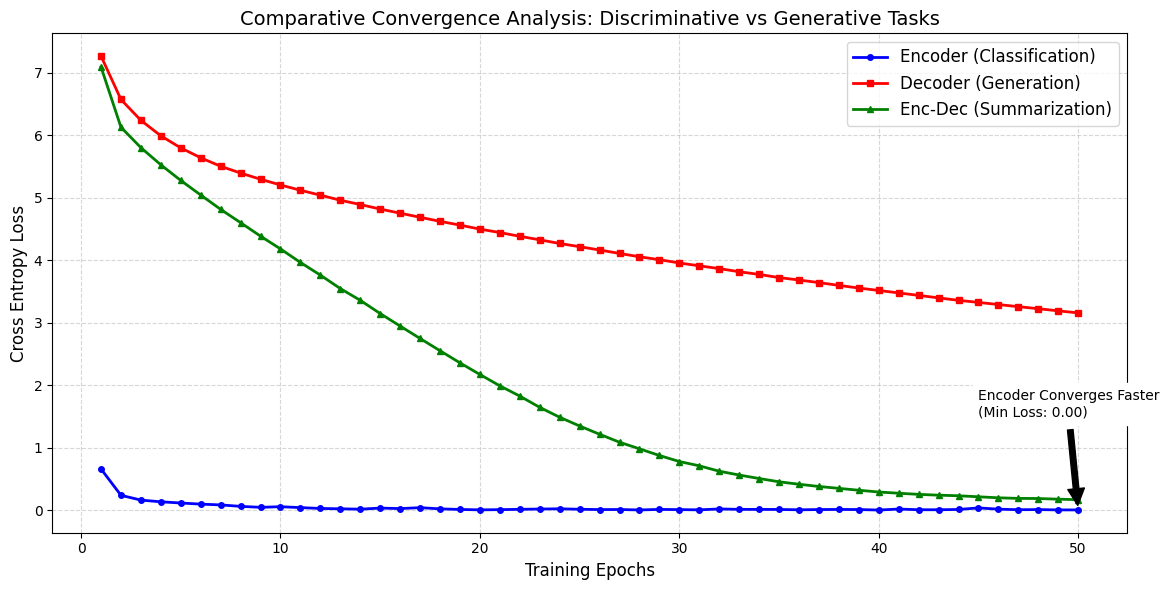



      🧪  PHASE 1: COMPREHENSIVE MODEL EVALUATION  🧪

[Test 1] Encoder: Classifying a New Abstract
Input: 'Deep neural networks have achieved state-of-the-art results in image recognition.'
Predicted Class: 1 (Network)

[Test 2] Decoder: Autocomplete Sentence
Prompt: 'the results show ...'
Generated: is a powerful tool for learning tasks in reinforcement learning

[Test 3] Encoder-Decoder: Summarization
Input: Due to the success of deep learning to solving a variety of challenging machine learning tasks, ther...
Generated: we provide necessary and sufficient analytical forms for the critical points of the square loss functions for the square loss functions for the square loss functions of these neural networks


In [12]:
# 6. Main Execution
def run_robust_training():
    # Load Data
    raw_data = download_data()

    # Build Vocabulary
    tokenizer = SimpleTokenizer(max_vocab_size=8000)
    all_texts = [" ".join(x['source']) for x in raw_data] + [x['target'][0] for x in raw_data]
    tokenizer.build_vocab(all_texts)

    # Hyperparameters
    BATCH_SIZE = 32
    LR = 0.0003
    EPOCHS = 50
    D_MODEL = 256
    HEADS = 4
    LAYERS = 4
    D_FF = 256

    print("Batch Size:", BATCH_SIZE)
    print("Learning Rate:", LR)
    print("Epochs:", EPOCHS)
    print("D Model:", D_MODEL)
    print("Heads:", HEADS)
    print("Layers:", LAYERS)
    print("FF Layers:", D_FF)


    # Lists to store loss history
    enc_history = []
    dec_history = []
    seq_history = []

    # Task 1: Encoder Only (Classification)
    print("\n=== [Task 1] Training Encoder (Keyword Classification) ===")
    train_ds = ScienceDataset(raw_data, tokenizer, task="classification")
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

    encoder_model = EncoderTransformer(tokenizer.vocab_size, D_MODEL, HEADS, LAYERS, D_FF, num_classes=3).to(device)
    optimizer = optim.Adam(encoder_model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    encoder_model.train()
    for epoch in range(EPOCHS):
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            mask, _ = create_masks(x)
            logits = encoder_model(x, mask)
            loss = criterion(logits, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Save Loss
        avg_loss = total_loss / len(train_loader)
        enc_history.append(avg_loss)
        print(f"Epoch {epoch+1} Loss: {avg_loss:.4f}")

    # Task 2: Decoder Only (Next Token)
    print("\n=== [Task 2] Training Decoder (Abstract Generation) ===")
    train_ds = ScienceDataset(raw_data, tokenizer, task="generation")
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

    decoder_model = DecoderTransformer(tokenizer.vocab_size, D_MODEL, HEADS, LAYERS, D_FF).to(device)
    optimizer = optim.Adam(decoder_model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss(ignore_index=0)

    decoder_model.train()
    for epoch in range(EPOCHS):
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            _, mask = create_masks(x, x, pad_idx=0)
            logits = decoder_model(x, mask)
            loss = criterion(logits.reshape(-1, tokenizer.vocab_size), y.reshape(-1))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Save Loss
        avg_loss = total_loss / len(train_loader)
        dec_history.append(avg_loss)
        print(f"Epoch {epoch+1} Loss: {avg_loss:.4f}")

    # Task 3: Encoder Decoder (Summarization)
    print("\n=== [Task 3] Training Encoder-Decoder (Abstract -> TLDR) ===")
    train_ds = ScienceDataset(raw_data, tokenizer, task="seq2seq")
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

    encoder_decoder_model = EncoderDecoderTransformer(tokenizer.vocab_size, D_MODEL, HEADS, LAYERS, D_FF).to(device)
    optimizer = optim.Adam(encoder_decoder_model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss(ignore_index=0)

    encoder_decoder_model.train()
    for epoch in range(EPOCHS):
        total_loss = 0
        for src, tgt in train_loader:
            src, tgt = src.to(device), tgt.to(device)
            tgt_in, tgt_out = tgt[:, :-1], tgt[:, 1:]

            src_mask, tgt_mask = create_masks(src, tgt_in, pad_idx=0)
            logits = encoder_decoder_model(src, tgt_in, src_mask, tgt_mask)
            loss = criterion(logits.reshape(-1, tokenizer.vocab_size), tgt_out.reshape(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Save Loss
        avg_loss = total_loss / len(train_loader)
        seq_history.append(avg_loss)
        print(f"Epoch {epoch+1} Loss: {avg_loss:.4f}")

    # Generate Plot
    print("\n>>> Generating Comparison Plot...")
    plot_exemplary_comparison(enc_history, dec_history, seq_history)

    print("\n\n=======================================================")
    print("      🧪  PHASE 1: COMPREHENSIVE MODEL EVALUATION  🧪")
    print("=======================================================")

    # --- TEST 1: ENCODER-ONLY (Classification) ---
    print("\n[Test 1] Encoder: Classifying a New Abstract")
    # A fake abstract about Neural Networks (Should be Class 1: 'Network')
    test_text_enc = "Deep neural networks have achieved state-of-the-art results in image recognition."
    print(f"Input: '{test_text_enc}'")

    encoder_model.eval()
    with torch.no_grad():
        # Prepare input
        x = torch.tensor([tokenizer.encode(test_text_enc)]).to(device)
        mask, _ = create_masks(x)

        # Forward pass
        logits = encoder_model(x, mask)

        # Get prediction (Argmax)
        pred_id = torch.argmax(logits, dim=-1).item()

    # Map back to class names (Reverse of your dataset logic)
    class_map = {0: "Learning", 1: "Network", 2: "Other"}
    print(f"Predicted Class: {pred_id} ({class_map.get(pred_id, 'Unknown')})")

    # --- TEST 2: DECODER-ONLY (Text Completion) ---
    print("\n[Test 2] Decoder: Autocomplete Sentence")
    test_text_dec = "the results show"  # A common starting phrase
    print(f"Prompt: '{test_text_dec} ...'")

    decoder_model.eval()
    with torch.no_grad():
        # Start with the prompt
        curr = torch.tensor([tokenizer.encode(test_text_dec)[:-1]]).to(device) # Remove EOS
        generated = []

        for _ in range(10): # Generate 10 words
            # Create Causal Mask
            _, mask = create_masks(curr, curr, pad_idx=0)

            # Forward pass
            out = decoder_model(curr, mask)

            # Greedy decode: Pick best next word
            next_id = torch.argmax(out[:, -1, :]).item()

            # Append and continue
            generated.append(next_id)
            curr = torch.cat([curr, torch.tensor([[next_id]]).to(device)], dim=1)

            if next_id == 3: break # Stop at EOS

    print(f"Generated: {tokenizer.decode(generated)}")

    # --- TEST 3: ENCODER_DECODER (Summary) ---
    print("\n[Test 3] Encoder-Decoder: Summarization")
    encoder_decoder_model.eval()
    sample_item = raw_data[0]
    sample_text = " ".join(sample_item['source'])
    print(f"Input: {sample_text[:100]}...")

    src_ids = torch.tensor([tokenizer.encode(sample_text)]).to(device)
    src_mask, _ = create_masks(src_ids)
    memory = encoder_decoder_model.encode(src_ids, src_mask)

    curr = torch.tensor([[2]]).to(device)
    res = [2]

    for _ in range(30):
        _, tgt_mask = create_masks(src_ids, curr)
        out = encoder_decoder_model.decode(curr, memory, src_mask, tgt_mask)
        next_id = torch.argmax(out[:, -1, :]).item()
        res.append(next_id)
        curr = torch.cat([curr, torch.tensor([[next_id]]).to(device)], dim=1)
        if next_id == 3: break

    print(f"Generated: {tokenizer.decode(res)}")

if __name__ == "__main__":
    run_robust_training()